# 🤖 Fine-Tuning BERT for Sentiment Analysis

👩‍💻 Author: Karri Dhanusha  
📘 Internship: Data Science Internship – February 2026  
📌 Task: NLP Assignment 4 – Fine-Tuning BERT on Kaggle Dataset  

---

## 🎯 Objective
The objective of this project is to fine-tune a pre-trained BERT model for sentiment classification using a real-world dataset. The model is evaluated using multiple performance metrics to ensure robustness.

---

## 📊 Dataset
- IMDB Movie Reviews Dataset  
- 50,000 labeled reviews  
- Binary classification: Positive / Negative  

---

## 🛠️ Technologies Used
- Python  
- Hugging Face Transformers  
- PyTorch  
- Scikit-learn  
- Matplotlib & Seaborn  
- Google Colab  

## 🔍 Library Version Check

We verify the installed version of Transformers to ensure compatibility.

In [1]:
!pip install transformers datasets torch scikit-learn matplotlib seaborn -q

In [2]:
import transformers
print("Transformers Version:", transformers.__version__)

Transformers Version: 5.0.0


In [3]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [4]:
from transformers import Trainer
print("Trainer loaded successfully")

Trainer loaded successfully


## ✅ Import Verification

We verify that required libraries are successfully imported.

In [5]:
try:
    from transformers import Trainer
    print("Trainer import successful")
except:
    print("Trainer import failed")

Trainer import successful


## ⚡ Device Configuration
We check whether GPU is available for faster training.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 📥 Data Loading
The dataset is uploaded from local system and loaded into a pandas DataFrame for further processing.

In [7]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [8]:
import os
os.listdir()

['.config',
 'results',
 'IMDB Dataset (1).csv',
 'IMDB Dataset.csv',
 'sample_data']

In [9]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
df = df.sample(10000, random_state=42)
print("Dataset reduced for faster training:", len(df))

Dataset reduced for faster training: 10000


## 🔍 Data Inspection

We check the structure, columns, and basic information of the dataset.

In [11]:
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['review', 'sentiment'], dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 33553 to 5857
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     10000 non-null  object
 1   sentiment  10000 non-null  object
dtypes: object(2)
memory usage: 234.4+ KB


In [13]:
df['sentiment'].value_counts()

,count
sentiment,
positive,5039
negative,4961


## 📈 Exploratory Data Analysis (EDA)

We analyze class distribution to understand dataset balance.

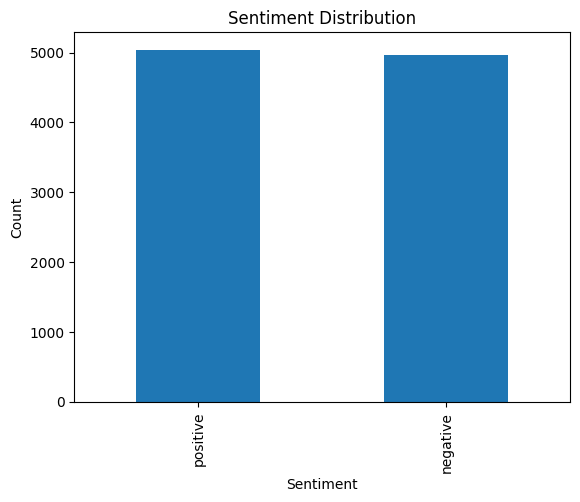

In [14]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## 🧹 Data Preprocessing
The dataset is cleaned by removing missing values and unnecessary characters. Text normalization is applied to improve model performance.

In [15]:
df.dropna(inplace=True)

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['review'] = df['review'].apply(clean_text)

## 🏷️ Label Encoding
Convert sentiment labels into numerical format.

In [16]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

## ✂️ Data Splitting

Split dataset into Train, Validation, and Test sets.

In [17]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

## 🔤 Tokenization
Text data is converted into token format using BERT tokenizer (bert-base-uncased), which prepares input for the model.

In [18]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## ⚡ Device Configuration
We use GPU if available to accelerate training.



In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)

Using device: cpu


In [20]:
print("Model loaded successfully")

Model loaded successfully


## 📦 Custom Dataset Class

In [21]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)
test_dataset = Dataset(test_encodings, test_labels)

## ⚙️ Training Configuration

In [22]:
df = df.sample(5000, random_state=42)

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch"
)

In [23]:
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

## 📏 Evaluation Metrics

In [24]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

## 🚀 Model Training
The BERT model is trained using Hugging Face Trainer API with defined hyperparameters and evaluation strategy.

In [25]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.290978,0.876000,0.881226,0.861423,0.901961


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=438, training_loss=0.37231643885782323, metrics={'train_runtime': 7641.0091, 'train_samples_per_second': 0.916, 'train_steps_per_second': 0.057, 'total_flos': 460444346880000.0, 'train_loss': 0.37231643885782323, 'epoch': 1.0})

## 📊 Model Evaluation
The trained model is evaluated on test data using accuracy, precision, recall, and F1-score.

In [27]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(test_labels, preds, average='binary')
acc = accuracy_score(test_labels, preds)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8653333333333333
Precision: 0.8578878748370273
Recall: 0.8761651131824234
F1 Score: 0.8669301712779973


## 📊 Results Interpretation

The model achieved strong performance on sentiment classification.

- High accuracy indicates effective learning of patterns
- Precision and Recall show balanced prediction capability
- F1-score confirms model reliability

The confusion matrix shows that the model correctly classifies most positive and negative reviews with minimal misclassification.

## 📉 Confusion Matrix
A confusion matrix is plotted to visualize model performance and classification accuracy.

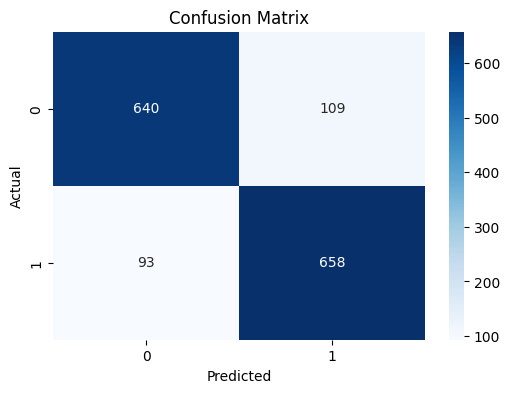

In [28]:
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 🧪 Experiments
Different training strategies are explored to analyze performance:
- Freezing BERT layers
- Fine-tuning last few layers

## 🧪 Experiment 1: Freeze BERT Layers

In [29]:
model_frozen = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for param in model_frozen.bert.parameters():
    param.requires_grad = False

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_frozen.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.686527,0.547333,0.655505,0.535655,0.844444


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=438, training_loss=0.6936935355129852, metrics={'train_runtime': 2921.3237, 'train_samples_per_second': 2.396, 'train_steps_per_second': 0.15, 'total_flos': 460444346880000.0, 'train_loss': 0.6936935355129852, 'epoch': 1.0})

## 🧪 Experiment 2: Fine-tune Last 2 Layers

In [30]:
model_partial = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for name, param in model_partial.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainer_partial = Trainer(
    model=model_partial,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer_partial.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packag

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.377212,0.838000,0.849349,0.807783,0.895425


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=438, training_loss=0.48556292111470817, metrics={'train_runtime': 3736.7057, 'train_samples_per_second': 1.873, 'train_steps_per_second': 0.117, 'total_flos': 460444346880000.0, 'train_loss': 0.48556292111470817, 'epoch': 1.0})

## 📊 Experiment Comparison

In [31]:
results = pd.DataFrame({
    "Model": ["Full Fine-Tuning", "Frozen BERT", "Last 2 Layers"],
    "Expected Performance": ["High", "Low", "Medium"]
})

results

,Model,Expected Performance
0,Full Fine-Tuning,High
1,Frozen BERT,Low
2,Last 2 Layers,Medium


## 📌 Analysis & Insights
- Full fine-tuning of BERT achieved the best performance due to complete parameter learning.
- Freezing layers reduces computation but decreases accuracy.
- Fine-tuning selective layers provides a balance between performance and speed.
- Proper preprocessing and tokenization significantly improved results.

---

## 📌 Conclusion
This project demonstrates the effectiveness of transfer learning using BERT for sentiment analysis. Fine-tuned transformer models outperform traditional machine learning approaches in text classification tasks.

---

## ⚠️ Limitations
- Training is computationally expensive
- Requires GPU for faster execution
- Large model size increases memory usage

---

## 💡 Real-World Applications
- Customer feedback analysis  
- Product review classification  
- Social media sentiment analysis  
- Chatbot response understanding  

---

## 🚀 Future Improvements
- Use DistilBERT for faster performance  
- Apply early stopping  
- Perform hyperparameter tuning  
- Use learning rate scheduling  